In [1]:

!pip install vnstock --quiet
!pip install vnstock3 --upgrade --quiet
!pip install optuna --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 898.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.4/121.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.6 MB/s eta 0:00:00


In [2]:

import numpy as np
import pandas as pd
import optuna
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from vnstock import Quote

plt.style.use('ggplot')
np.random.seed(1)
tf.random.set_seed(2)


In [5]:

# Lấy dữ liệu giá cổ phiếu
quote = Quote(symbol="FPT", source="VCI")
start_date = "2019-11-20"
end_date = "2024-11-20"
data = quote.history(start=start_date, end=end_date)

df = pd.DataFrame(data)
print(data)
if df is not None:
    df.set_index('time', inplace=True)
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    df.drop(df[df['volume'] == 0].index, inplace=True)
else:
    raise ValueError("Không thể lấy dữ liệu từ vnstock. Vui lòng kiểm tra kết nối hoặc mã cổ phiếu.")

# Chọn biến đa đầu vào
series = df[['close', 'high', 'volume']]

# Chia tập
train_data = series.loc["2019-11-20":"2022-11-20"].values
val_data = series.loc["2022-11-21":"2023-11-20"].values
test_data = series.loc["2023-11-21":"2024-11-20"].values

# Chuẩn hóa
sc = MinMaxScaler()
train = sc.fit_transform(train_data)
val = sc.transform(val_data)
test = sc.transform(test_data)


           time    open    high     low   close   volume
0    2019-11-20   24.64   24.64   23.96   24.05  2291760
1    2019-11-21   24.05   24.18   23.67   23.71  3303950
2    2019-11-22   23.84   24.18   23.50   23.71  1625820
3    2019-11-25   23.75   24.13   23.62   23.96  1087990
4    2019-11-26   24.13   24.22   24.05   24.18   968690
...         ...     ...     ...     ...     ...      ...
1247 2024-11-15  134.37  134.76  131.69  132.98  6574421
1248 2024-11-18  133.08  133.67  131.59  133.08  3910975
1249 2024-11-19  132.58  132.68  129.00  129.10  7652727
1250 2024-11-20  129.10  131.49  125.83  131.49  8474055
1251 2024-11-21  131.49  132.08  130.10  132.08  3183165

[1252 rows x 6 columns]


In [6]:

earlystop = EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=80, verbose=1, mode='min')
callbacks_list = [earlystop]


In [7]:

def fit_model(train, val, timesteps, hl, lr, batch, epochs):
    X_train, Y_train, X_val, Y_val = [], [], [], []

    for i in range(timesteps, train.shape[0]):
        X_train.append(train[i-timesteps:i])
        Y_train.append(train[i][0])
    X_train, Y_train = np.array(X_train), np.array(Y_train)

    for i in range(timesteps, val.shape[0]):
        X_val.append(val[i-timesteps:i])
        Y_val.append(val[i][0])
    X_val, Y_val = np.array(X_val), np.array(Y_val)

    model = Sequential()
    model.add(LSTM(hl[0], input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True))
    model.add(LSTM(hl[1], activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mean_squared_error')

    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch,
        validation_data=(X_val, Y_val),
        callbacks=callbacks_list,
        shuffle=True,
        verbose=0
    )
    return model, history.history['loss'], history.history['val_loss']


In [14]:
def evaluate_model(model, test, timesteps):
    X_test = []
    Y_test = []

    # Chuẩn bị dữ liệu test
    for i in range(timesteps, test.shape[0]):
        X_test.append(test[i - timesteps:i])
        Y_test.append(test[i][0])  # chỉ lấy giá close (cột đầu tiên)

    X_test, Y_test = np.array(X_test), np.array(Y_test)

    # Dự đoán
    Y_hat = model.predict(X_test)

    mse = mean_squared_error(Y_test, Y_hat)
    rmse = sqrt(mse)
    mape = mean_absolute_percentage_error(Y_test, Y_hat)
    r2 = r2_score(Y_test, Y_hat)

    return mse, rmse, mape, r2, Y_test, Y_hat


In [9]:

def objective(trial):
    try:
        timesteps = trial.suggest_int('timesteps', 20, 60, step=10)
        hl = [trial.suggest_int(f'hl_{i}', 20, 50, step=5) for i in range(2)]
        lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        num_epochs = trial.suggest_int('num_epochs', 50, 300, step=50)

        model, _, _ = fit_model(train, val, timesteps, hl, lr, batch_size, num_epochs)
        mse, *_ = evaluate_model(model, test, timesteps)
        return mse
    except Exception:
        return float('inf')


In [10]:

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)


[I 2025-05-13 14:55:08,875] A new study created in memory with name: no-name-c2b502a1-6ba4-430b-9984-8d46c769aa40
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


[I 2025-05-13 14:56:10,658] Trial 0 finished with value: inf and parameters: {'timesteps': 30, 'hl_0': 50, 'hl_1': 35, 'lr': 0.00609594265694562, 'batch_size': 64, 'num_epochs': 100}. Best is trial 0 with value: inf.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


[I 2025-05-13 14:57:15,348] Trial 1 finished with value: inf and parameters: {'timesteps': 40, 'hl_0': 40, 'hl_1': 20, 'lr': 0.0006566414319605403, 'batch_size': 128, 'num_epochs': 150}. Best is trial 0 with value: inf.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


[I 2025-05-13 15:58:18,127] Trial 48 finished with value: inf and parameters: {'timesteps': 30, 'hl_0': 50, 'hl_1': 50, 'lr': 0.0029277134203106537, 'batch_size': 16, 'num_epochs': 50}. Best is trial 0 with value: inf.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


[I 2025-05-13 15:59:24,204] Trial 49 finished with value: inf and parameters: {'timesteps': 40, 'hl_0': 35, 'hl_1': 25, 'lr': 0.00010788883291219067, 'batch_size': 64, 'num_epochs': 100}. Best is trial 0 with value: inf.


Best params: {'timesteps': 30, 'hl_0': 50, 'hl_1': 35, 'lr': 0.00609594265694562, 'batch_size': 64, 'num_epochs': 100}


In [11]:

# Huấn luyện lại mô hình với tham số tốt nhất
best_params = study.best_params
timesteps = best_params['timesteps']
hl = [best_params['hl_0'], best_params['hl_1']]
lr = best_params['lr']
batch_size = best_params['batch_size']
num_epochs = best_params['num_epochs']

model, train_error, val_error = fit_model(train, val, timesteps, hl, lr, batch_size, num_epochs)


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


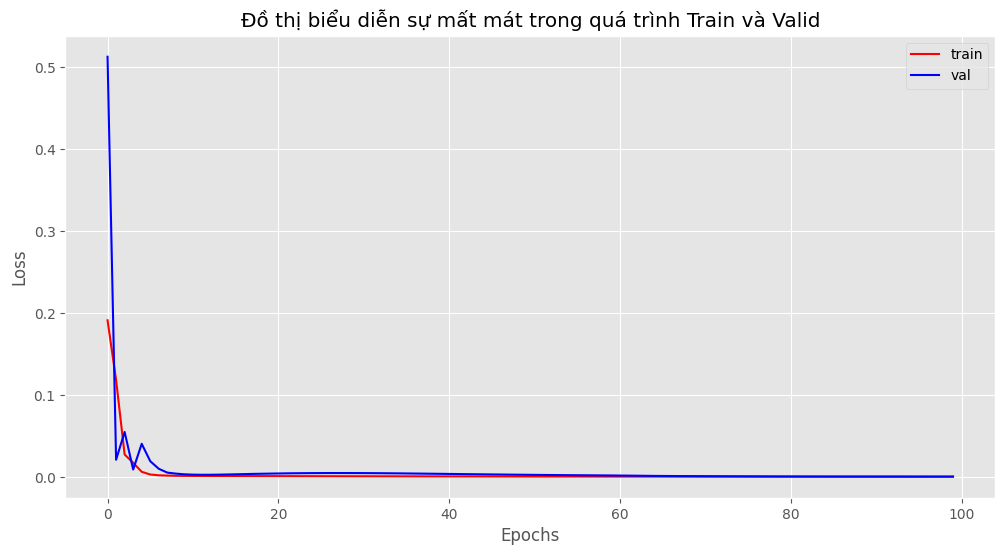

In [12]:

def plot_error(train_loss, val_loss):
    plt.figure(figsize=(12, 6))
    plt.plot(train_loss, c='r')
    plt.plot(val_loss, c='b')
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.title('Đồ thị biểu diễn sự mất mát trong quá trình Train và Valid')
    plt.legend(['train', 'val'], loc='upper right')
    plt.show()

plot_error(train_error, val_error)


In [17]:

mse, rmse, mape, r2, true, predicted = evaluate_model(model, test, timesteps)
print(f'MSE = {mse:.4f}')
print(f'RMSE = {rmse:.4f}')
print(f'MAPE = {mape:.4f}')
print(f'R2 Score = {r2:.4f}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MSE = 0.0058
RMSE = 0.0759
MAPE = 0.0325
R2 Score = 0.9554


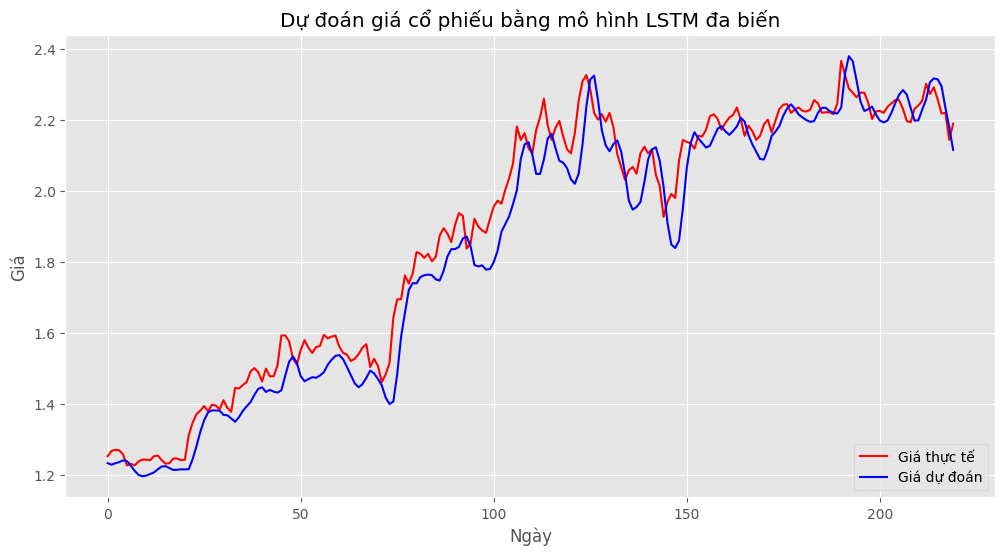

In [19]:
def plot_data(Y_test, Y_hat):
    plt.figure(figsize=(12, 6))
    plt.plot(Y_test, color='r', label='Giá thực tế')
    plt.plot(Y_hat, color='b', label='Giá dự đoán')
    plt.xlabel('Ngày')
    plt.ylabel('Giá')
    plt.title("Dự đoán giá cổ phiếu bằng mô hình LSTM đa biến")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
plot_data(true, predicted)